In [1]:
from PIL import Image
import numpy as np
import torch
import os
from torch.utils.data import Dataset, DataLoader
import torch
from torch import nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
import torchvision
import torchvision.transforms.v2 as T
from torchvision import tv_tensors
from glob import glob
import matplotlib.pyplot as plt
from transformers import SegformerForSemanticSegmentation
from sklearn.metrics import jaccard_score
from tqdm import tqdm

2026-01-25 12:56:00.043076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769345760.239218      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769345760.300005      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769345760.784075      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769345760.784111      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769345760.784115      55 computation_placer.cc:177] computation placer alr

In [2]:
def get_pre_disaster_image_mask_pairs(path):
    satellite_images = sorted(glob(os.path.join(path, 'images', '*_pre_disaster.png')))
    mask_images = sorted(glob(os.path.join(path, 'masks', '*_pre_disaster.png')))
    return list(zip(satellite_images, mask_images))

In [3]:
tier1 = get_pre_disaster_image_mask_pairs('/kaggle/input/xbd-dataset/xbd/tier1')
tier3 = get_pre_disaster_image_mask_pairs('/kaggle/input/xbd-dataset/xbd/tier3')
tier1.extend(tier3)
train_images = tier1

test_images = get_pre_disaster_image_mask_pairs('/kaggle/input/xbd-dataset/xbd/test')
len(train_images), len(test_images)

(9168, 933)

In [4]:
train_images[100]

('/kaggle/input/xbd-dataset/xbd/tier1/images/hurricane-florence_00000146_pre_disaster.png',
 '/kaggle/input/xbd-dataset/xbd/tier1/masks/hurricane-florence_00000146_pre_disaster.png')

In [5]:
class XBD_Building_Segmentation_Dataset(Dataset):
    def __init__(self, data, transform):
        self.data = data
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        img_path = self.data[idx][0]
        mask_path = self.data[idx][1]

        img = Image.open(img_path)
        mask = Image.open(mask_path)

        mask = tv_tensors.Mask(mask)

        img, mask = self.transform(img, mask)
        mask = (mask/255).squeeze(0).to(torch.long)

        return img, mask

In [6]:
train_transform = T.Compose([
    T.Resize((640, 640)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(size=(512, 512)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),  
])

val_transform = T.Compose([
    T.Resize((512, 512)),
    T.ToImage(), 
    T.ToDtype(torch.float32, scale=True),
])

In [7]:
train_dataset = XBD_Building_Segmentation_Dataset(train_images, train_transform)
test_dataset = XBD_Building_Segmentation_Dataset(test_images, val_transform)

In [8]:
len(train_dataset), len(test_dataset)

(9168, 933)

In [9]:
img, mask = train_dataset[7000]

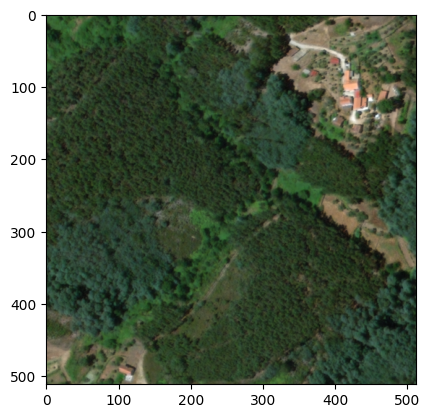

In [10]:
plt.imshow(img.permute(1,2,0))

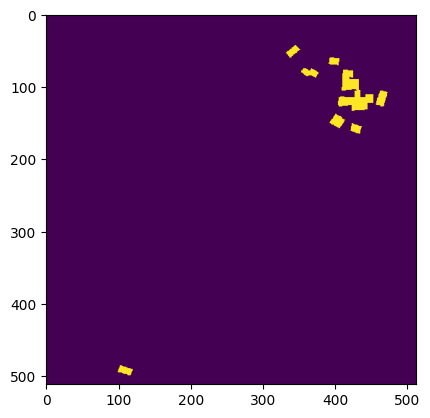

In [11]:
plt.imshow(mask.unsqueeze(2))

In [12]:
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=8,
                              shuffle=True,
                              num_workers=2,
                              prefetch_factor=3,
                              pin_memory=True)
test_dataloader = DataLoader(dataset=test_dataset,
                              batch_size=8,
                              shuffle=False,
                              num_workers=2,
                              prefetch_factor=3,
                              pin_memory=True)

In [13]:
img, mask = next(iter(train_dataloader))

In [14]:
img.shape, mask.shape

(torch.Size([8, 3, 512, 512]), torch.Size([8, 512, 512]))

In [15]:
scaler = GradScaler('cuda')

def train_step(model, dataloader, optimizer, loss_fn, epoch, device='cuda'):
    model.train()
    total_iou, train_loss = 0, 0

    pbar = tqdm(dataloader, desc=f"Train Epoch {epoch}")
    
    for img, mask in pbar:
        img, mask = img.to(device), mask.to(device)
        with autocast('cuda'):
            outputs = model(img)
            logits = outputs.logits
            
            mask = torch.nn.functional.interpolate(
                mask.unsqueeze(1).float(),
                size=logits.shape[-2:],
                mode="nearest"
            ).long()
            
            loss = loss_fn(logits, mask)

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        
        preds = (torch.sigmoid(logits) > 0.5).int()
        intersection = ((preds == 1) & (mask == 1)).sum()
        union = ((preds == 1) | (mask == 1)).sum()

        batch_iou = intersection.float() / (union.float() + 1e-6)
        total_iou += batch_iou.item()

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            iou=f"{batch_iou.item():.4f}"
        )

    iou = total_iou/len(dataloader)
    avg_loss = train_loss/len(dataloader)
    print(f"Epoch: {epoch} | Train Loss: {avg_loss:.4f} | IoU: {iou:.4f}")

def test_step(model, dataloader, loss_fn, epoch, device='cuda'):
    model.eval()
    total_iou, test_loss = 0, 0

    pbar = tqdm(dataloader, desc=f"Test Epoch {epoch}")

    with torch.inference_mode():
        for img, mask in pbar:
            img, mask = img.to(device), mask.to(device)
            with autocast('cuda'):
                outputs = model(img)
                logits = outputs.logits
                
                mask = torch.nn.functional.interpolate(
                    mask.unsqueeze(1).float(),
                    size=logits.shape[-2:],
                    mode="nearest"
                ).long()
                
                loss = loss_fn(logits, mask)
    
            test_loss += loss.item()
            
            preds = (torch.sigmoid(logits) > 0.5).int()
            intersection = ((preds == 1) & (mask == 1)).sum()
            union = ((preds == 1) | (mask == 1)).sum()

            batch_iou = intersection.float() / (union.float() + 1e-6)
            total_iou += batch_iou.item()

            pbar.set_postfix(
                loss=f"{loss.item():.4f}",
                iou=f"{batch_iou.item():.4f}"
            )

    iou = total_iou/len(dataloader)
    avg_loss = test_loss/len(dataloader)
    print(f"Epoch: {epoch} | Test Loss: {avg_loss:.4f} | IoU: {iou:.4f}")

In [16]:
def dice_loss(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)
    targets = targets.float()

    intersection = (probs * targets).sum(dim=(2,3))
    union = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))

    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model = SegformerForSemanticSegmentation.from_pretrained(
    'nvidia/segformer-b0-finetuned-ade-512-512',
    num_labels=1,
    ignore_mismatched_sizes=True
).to('cuda')

model = nn.DataParallel(model)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
bce_loss = torch.nn.BCEWithLogitsLoss()

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([1, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
def loss_fn(logits, targets, alpha=0.5):
    bce = F.binary_cross_entropy_with_logits(logits, targets.float())
    dice = dice_loss(logits, targets)
    return alpha * bce + (1 - alpha) * dice

In [ ]:
current = 0
num_epochs = 15

start = 1 + current
epochs = num_epochs + current + 1

print(f"Running from {start} to {epochs-1}")

torch.manual_seed(42)
torch.cuda.manual_seed(42)

print("Ready to train!!")

for epoch in range(start, epochs):
    train_step(
        model=model,
        optimizer=optimizer,
        loss_fn=loss_fn,
        epoch=epoch,
        dataloader=train_dataloader
    )

    test_step(
        model=model,
        loss_fn=loss_fn,
        epoch=epoch,
        dataloader=test_dataloader,
    )
    checkpoint = model.state_dict()
    torch.save(obj=checkpoint, f=f"Building_SegFormer_{epoch}_epochs.pth")

Running from 1 to 40
Ready to train!!


Train Epoch 1:   0%|          | 0/1146 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

Train Epoch 1: 100%|██████████| 1146/1146 [15:16<00:00,  1.25it/s, iou=0.5502, loss=0.3924]


Epoch: 1 | Train Loss: 0.4624 | IoU: 0.5068


...

Train Epoch 20: 100%|██████████| 1146/1146 [14:48<00:00,  1.29it/s, iou=0.0000, loss=nan]  


Epoch: 20 | Train Loss: nan | IoU: 0.0002


Test Epoch 20: 100%|██████████| 117/117 [01:14<00:00,  1.57it/s, iou=0.0000, loss=nan]


Epoch: 20 | Test Loss: nan | IoU: 0.0000


Train Epoch 21:  89%|████████▉ | 1020/1146 [13:10<01:36,  1.31it/s, iou=0.0000, loss=nan]

In [ ]:
checkpoint = model.state_dict()

In [ ]:
torch.save(obj=checkpoint, f=f"Building_SegFormer_{epochs-1}_epochs.pth")